# 02 - Baselines

Two references, neither of which counts as one of the three graded models:

1. **Most frequent class** - always predicts "real". Proves the accuracy trap.
2. **TF-IDF -> Logistic Regression** - a genuine, and genuinely strong, bar to clear.

**Protocol used in every model notebook:** train on train, tune the decision
threshold on **validation**, and report on **test** at that frozen threshold. Test
is never used to make a choice.

In [2]:
import sys
from pathlib import Path

# Make `src` importable whether this runs from notebooks/ or the project root.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import config, evaluation, features, models, preprocessing

config.set_seed()
config.ensure_dirs()
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

In [3]:
train, val, test = preprocessing.load_splits()
for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:>5}: {len(part):>6,} rows, {part[config.TARGET].mean():.2%} fraudulent")

y_train, y_val, y_test = (part[config.TARGET].to_numpy() for part in (train, val, test))

train: 12,319 rows, 4.87% fraudulent
  val:  2,640 rows, 4.85% fraudulent
 test:  2,640 rows, 4.85% fraudulent


## 1. Most-frequent baseline

In [4]:
dummy = models.train_most_frequent_baseline(train[[config.FULL_TEXT_COLUMN]], y_train)

# Train and validation are evaluated separately, never in one wrapped call.
dummy_train_metrics = evaluation.evaluate_predictions(
    y_train, models.predict_proba(dummy, train[[config.FULL_TEXT_COLUMN]]))
dummy_val_metrics = evaluation.evaluate_predictions(
    y_val, models.predict_proba(dummy, val[[config.FULL_TEXT_COLUMN]]))

print("train:", {k: round(v, 4) for k, v in dummy_train_metrics.items()})
print("val:  ", {k: round(v, 4) for k, v in dummy_val_metrics.items()})
print(f"\n-> {dummy_val_metrics['accuracy']:.2%} accuracy, recall {dummy_val_metrics['recall']:.0%}. "
      "Every scam missed.")

evaluation.log_experiment("baseline_most_frequent", dummy_val_metrics, split="val",
                          notes="always predicts the majority class")

train: {'average_precision': np.float64(0.0487), 'roc_auc': np.float64(0.5), 'f1': 0.0, 'precision': 0.0, 'recall': 0.0, 'accuracy': 0.9513, 'threshold': 0.5}
val:   {'average_precision': np.float64(0.0485), 'roc_auc': np.float64(0.5), 'f1': 0.0, 'precision': 0.0, 'recall': 0.0, 'accuracy': 0.9515, 'threshold': 0.5}

-> 95.15% accuracy, recall 0%. Every scam missed.


{'timestamp': '2026-08-03T03:49:03',
 'model': 'baseline_most_frequent',
 'split': 'val',
 'average_precision': np.float64(0.048484848484848485),
 'roc_auc': np.float64(0.5),
 'f1': 0.0,
 'precision': 0.0,
 'recall': 0.0,
 'accuracy': 0.9515151515151515,
 'threshold': 0.5,
 'notes': 'always predicts the majority class'}

## 2. TF-IDF -> Logistic Regression

`class_weight="balanced"` so the minority class is not simply ignored.

In [5]:
logreg = models.train_tfidf_logreg(train[config.FULL_TEXT_COLUMN], y_train)

proba_train = models.predict_proba(logreg, train[config.FULL_TEXT_COLUMN])
proba_val = models.predict_proba(logreg, val[config.FULL_TEXT_COLUMN])

logreg_train_metrics = evaluation.evaluate_predictions(y_train, proba_train)
logreg_val_metrics = evaluation.evaluate_predictions(y_val, proba_val)

print("train:", {k: round(v, 4) for k, v in logreg_train_metrics.items()})
print("val:  ", {k: round(v, 4) for k, v in logreg_val_metrics.items()})
print(f"\ngap in AP (train - val): "
      f"{logreg_train_metrics['average_precision'] - logreg_val_metrics['average_precision']:.3f}"
      "  <- large gap means it is memorising")

train: {'average_precision': np.float64(0.9925), 'roc_auc': np.float64(0.9997), 'f1': 0.9317, 'precision': 0.8721, 'recall': 1.0, 'accuracy': 0.9929, 'threshold': 0.5}
val:   {'average_precision': np.float64(0.9092), 'roc_auc': np.float64(0.9915), 'f1': 0.8168, 'precision': 0.7985, 'recall': 0.8359, 'accuracy': 0.9818, 'threshold': 0.5}

gap in AP (train - val): 0.083  <- large gap means it is memorising


**Why the train–val gap is fine.** Train AP 0.99 vs val AP 0.91 — an 0.08 gap.
That's mild memorisation, and expected: TF-IDF exposes up to 50k features, and
logistic regression latches onto rare words seen in only a few training fakes —
those don't generalise, so train scores inflate. The honest number is **val AP
0.91**, ~19× the 0.048 base rate, and the bar the three graded models must beat.
Tightening `C` would narrow the gap, but a baseline sets the bar; it needn't be
perfect.

### Tune the threshold on validation

In [6]:
best_threshold, best_f2 = evaluation.tune_threshold(y_val, proba_val, beta=2.0)
print(f"best F2 threshold on val: {best_threshold:.3f}  (F2={best_f2:.3f})")

recall_threshold, recall_at_precision = evaluation.threshold_for_precision(
    y_val, proba_val, min_precision=0.9)
print(f"to hold 90% precision: threshold {recall_threshold:.3f}, "
      f"catching {recall_at_precision:.1%} of scams")

logreg_val_tuned = evaluation.evaluate_predictions(y_val, proba_val, threshold=best_threshold)
print("\nval @0.5:  ", {k: round(v, 3) for k, v in logreg_val_metrics.items()})
print("val @tuned:", {k: round(v, 3) for k, v in logreg_val_tuned.items()})

evaluation.log_experiment("baseline_tfidf_logreg", logreg_val_tuned, split="val",
                          notes=f"threshold tuned on val (F2), C={config.LOGREG_PARAMS['C']}")

best F2 threshold on val: 0.448  (F2=0.857)
to hold 90% precision: threshold 0.644, catching 75.8% of scams

val @0.5:   {'average_precision': np.float64(0.909), 'roc_auc': np.float64(0.992), 'f1': 0.817, 'precision': 0.799, 'recall': 0.836, 'accuracy': 0.982, 'threshold': 0.5}
val @tuned: {'average_precision': np.float64(0.909), 'roc_auc': np.float64(0.992), 'f1': 0.811, 'precision': 0.745, 'recall': 0.891, 'accuracy': 0.98, 'threshold': 0.448}


{'timestamp': '2026-08-03T04:08:19',
 'model': 'baseline_tfidf_logreg',
 'split': 'val',
 'average_precision': np.float64(0.9091728865714155),
 'roc_auc': np.float64(0.9915312748805731),
 'f1': 0.8113879003558719,
 'precision': 0.7450980392156863,
 'recall': 0.890625,
 'accuracy': 0.9799242424242425,
 'threshold': 0.44810457659057756,
 'notes': 'threshold tuned on val (F2), C=1.0'}

**Two operating points, one curve.** PR-AUC (0.91) is unchanged whichever we pick. We tune F2 (recall weighted 2× over precision) because a missed scam costs more than a false alarm: at t=0.45 we catch 89% of fakes at 75% precision. The precision-0.9 point is the cautious mirror — hold 90% precision and we still catch 76%. Same model, two policies for two costs of error. F2 is applied identically to every model so the precision/recall columns stay comparable across the experiments table.

### Report on test at the frozen threshold

In [7]:
proba_test = models.predict_proba(logreg, test[config.FULL_TEXT_COLUMN])
logreg_test_metrics = evaluation.evaluate_predictions(y_test, proba_test, threshold=best_threshold)
print("test:", {k: round(v, 4) for k, v in logreg_test_metrics.items()})

evaluation.log_experiment("baseline_tfidf_logreg", logreg_test_metrics, split="test",
                          notes="threshold frozen from val")
models.save_test_predictions("baseline_tfidf_logreg", y_test, proba_test)

test: {'average_precision': np.float64(0.9095), 'roc_auc': np.float64(0.9912), 'f1': 0.7774, 'precision': 0.7097, 'recall': 0.8594, 'accuracy': 0.9761, 'threshold': 0.4481}
Saved /content/Fake_Job_Postings_Detection/models/predictions_baseline_tfidf_logreg_test.csv


PosixPath('/content/Fake_Job_Postings_Detection/models/predictions_baseline_tfidf_logreg_test.csv')

Saved /content/Fake_Job_Postings_Detection/reports/figures/07_baseline_pr_curve.png


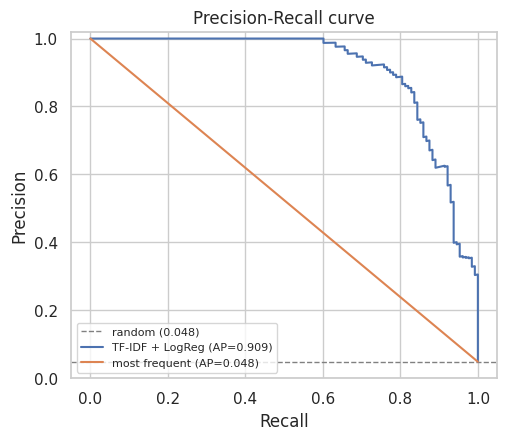

Saved /content/Fake_Job_Postings_Detection/reports/figures/08_baseline_confusion_matrix.png


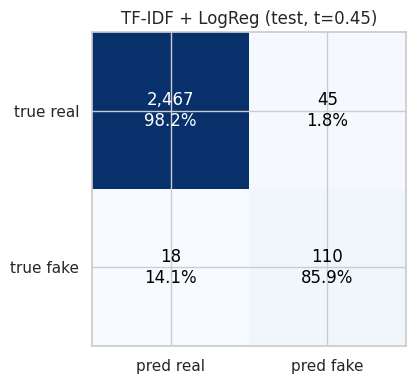

In [9]:
ax = evaluation.plot_pr_curve(y_test, proba_test, label="TF-IDF + LogReg")
evaluation.plot_pr_curve(y_test, models.predict_proba(dummy, test[[config.FULL_TEXT_COLUMN]]),
                         label="most frequent", ax=ax, save_as="07_baseline_pr_curve.png")
plt.show()

evaluation.plot_confusion_matrix(y_test, (proba_test >= best_threshold).astype(int),
                                 title=f"TF-IDF + LogReg (test, t={best_threshold:.2f})",
                                 save_as="08_baseline_confusion_matrix.png")
plt.show()

### Which words drive the decision?

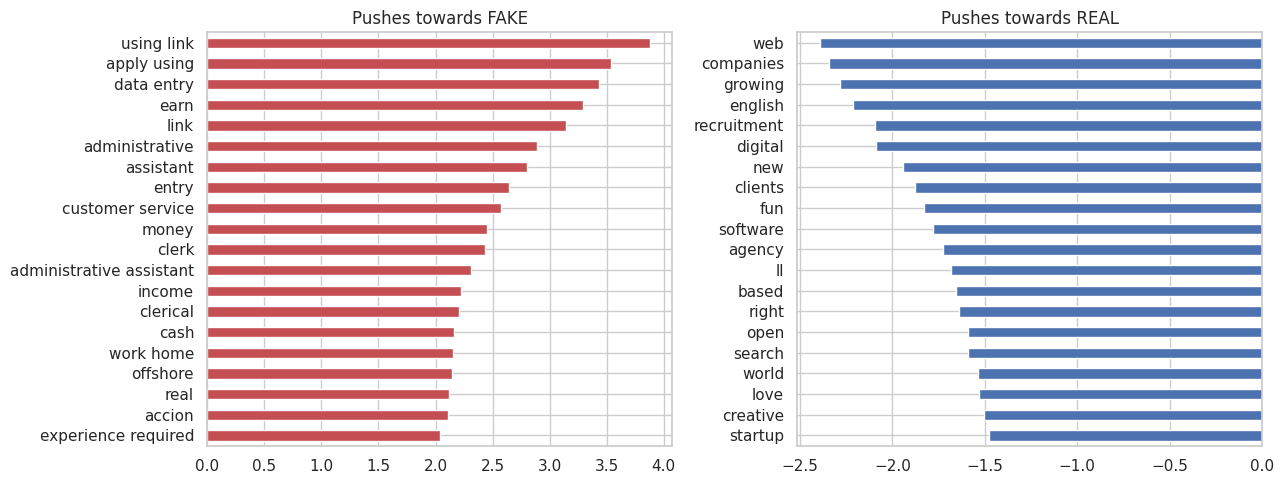

In [10]:
vectorizer = logreg.named_steps["tfidf"]
coefficients = logreg.named_steps["logreg"].coef_[0]
vocabulary = vectorizer.get_feature_names_out()

order = np.argsort(coefficients)
top_fake = pd.Series(coefficients[order[-20:]], index=vocabulary[order[-20:]])
top_real = pd.Series(coefficients[order[:20]], index=vocabulary[order[:20]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top_fake.plot.barh(ax=axes[0], color="#c44e52")
axes[0].set_title("Pushes towards FAKE")
top_real.sort_values(ascending=False).plot.barh(ax=axes[1], color="#4c72b0")
axes[1].set_title("Pushes towards REAL")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "09_baseline_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

**The model learns meaning, not noise.** The FAKE coefficients echo the EDA
directly: `data entry` and `work home` are the bigrams the word clouds surfaced,
and `money` / `earn` / `cash` mirror the has_money signal (fake 41% vs real 23%).
A cluster of low-skill bait roles — `administrative`, `assistant`, `clerk`,
`customer service` — fits the scam pattern of casting a wide net. `using link` /
`apply using` rank highest and are worth a look in the error analysis: likely an
attempt to move applicants off-platform. The REAL side (`software`, `startup`,
`agency`, `recruitment`) is concrete industry vocabulary — real posts describe
actual work, fakes lean on generic lures.

## Bar to clear

| model | what it shows |
|---|---|
| most frequent | ~95% accuracy, 0% recall. Accuracy is a lie. |
| TF-IDF + LogReg | The number the three graded models must beat. |

Run `evaluation.load_experiments()` at any point to see the log so far.

Next: `03_models_lightgbm.ipynb`.

In [11]:
evaluation.load_experiments()

,timestamp,model,split,average_precision,roc_auc,f1,precision,recall,accuracy,threshold,notes
0,2026-08-03T04:08:19,baseline_tfidf_logreg,val,0.909173,0.991531,0.811388,0.745098,0.890625,0.979924,0.448105,"threshold tuned on val (F2), C=1.0"
1,2026-08-03T03:49:03,baseline_most_frequent,val,0.048485,0.500000,0.000000,0.000000,0.000000,0.951515,0.500000,always predicts the majority class
